# Aruba population trends, 2015-2023

## Average domiciliation and departures by country

Source files: Table-1.11-Domiciliation-by-country-of-birth-and-sex.xlsx\
<span style="padding-left: 5.7em;">Table-1.12-Departures-by-country-of-birth-and-sex.xlsx</span>

Source: CBS Aruba and the Population Registry Office

---
## 1. Setup

### Imports and paths

The following block of code creates a reproducible notebook environment by using **import sys** and configuring the project path.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Establish paths

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_PROCESSED,
    FIGURES
)

In [2]:
# Verify all paths to ensure stable environment

print("ROOT:", ROOT)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/outputs/figures


In [3]:
# Load processed CSV data files

DOMICIL_PROCESSED = DATA_PROCESSED / "domiciliation_table.csv"

DEP_PROCESSED = DATA_PROCESSED / "departures_table.csv"

In [4]:
# Stop early if the source file is missing

if not DOMICIL_PROCESSED.exists():
    raise FileNotFoundError

if not DEP_PROCESSED.exists():
    raise FileNotFoundError

## 2. Load and inspect source data

In [5]:
# Assign varibles to both files

dom_df = pd.read_csv(DOMICIL_PROCESSED)
dep_df = pd.read_csv(DEP_PROCESSED)

In [6]:
# Initial inspection

print(dom_df.info())
print(dep_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Country  126 non-null    str  
 1   value    126 non-null    int64
 2   year     126 non-null    int64
 3   sex      126 non-null    str  
dtypes: int64(2), str(2)
memory usage: 6.3 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Country  126 non-null    str  
 1   value    126 non-null    int64
 2   year     126 non-null    int64
 3   sex      126 non-null    str  
dtypes: int64(2), str(2)
memory usage: 6.2 KB
None


In [7]:
dom_df.columns

Index(['Country', 'value', 'year', 'sex'], dtype='str')

### Basic statistics calculations

Here we use the describe function to calculate all the descriptive statistics of both the **domiciliation** and the **departures** data frames.

In [8]:
total_dom_df = dom_df[dom_df["Country"].eq("Total Domociliation")].copy()
country_dom_df = dom_df[~dom_df["Country"].eq("Total Domiciliation")].copy()

country_dom_df["value"].describe()

count     126.000000
mean      390.920635
std       425.570255
min        27.000000
25%       163.750000
50%       255.000000
75%       370.750000
max      1815.000000
Name: value, dtype: float64

In [9]:
total_dep_df = dep_df[dep_df["Country"].eq("Total Departures")].copy()
country_dep_df = dep_df[~dep_df["Country"].eq("Total Departures")].copy()

country_dep_df["value"].describe()

count     126.000000
mean      431.841270
std       506.111883
min        26.000000
25%        79.500000
50%       205.500000
75%       724.000000
max      1849.000000
Name: value, dtype: float64

**Summary statistics were calculated separately for total rows and country-level rows. Total rows were excluded from country-level descriptive statistics to avoid mixing aggregate values with subcategory values.**\
\
Country-level summaries show that departure values are not evenly distributed across origin categories. The category Aruba/ Neth. Ant. has substantially higher departure counts than all other groups, which raises the overall departure mean. For most other country categories, average domiciliation exceeds average departures.

| Variabele     | Count |   Mean |    Std | Min | Median | Max |
| ------------- | ----: | -----: | -----: | --: | -----: | --: |
| Domiciliation |   108 | 228.04 | 111.09 |  27 | 230.50 | 432 |
| Departures    |   108 | 251.91 | 258.14 |  26 | 162.00 | 933 |


In [10]:
country_dom_df.groupby("Country")["value"].agg(
    count="count",
    min="min",
    median="median",
    mean="mean",
    max="max",
).sort_values("mean", ascending=False)

,count,min,median,mean,max
Country,,,,,
Total Domiciliation:,18,882,1366.5,1368.222222,1815
Aruba/ Neth. Ant.,18,295,382.0,378.555556,432
Other,18,135,256.0,266.277778,416
The Netherlands,18,186,256.0,257.722222,370
Venezuela,18,111,199.5,216.611111,381
Colombia,18,82,171.5,171.333333,290
Dominican Republic,18,27,69.0,77.722222,184


In [11]:
country_dep_df.groupby("Country")["value"].agg(
    count="count",
    min="min",
    median="median",
    mean="mean",
    max="max"
).sort_values("mean", ascending=False)

,count,min,median,mean,max
Country,,,,,
Total Departures:,18,1298,1503.0,1511.444444,1849
Aruba/ Neth. Ant.,18,607,821.5,789.111111,933
The Netherlands,18,207,292.5,276.388889,352
Other,18,97,201.0,196.388889,275
Colombia,18,63,122.5,132.111111,253
Dominican Republic,18,26,51.0,60.888889,120
Venezuela,18,42,53.5,56.555556,85


In [12]:
summary = (
    country_dom_df.groupby("Country")["value"]
    .agg(mean_domiciliation="mean", median_domiciliation="median")
    .join(
        country_dep_df.groupby("Country")["value"]
        .agg(mean_departures="mean", median_departures="median")
    )
)

summary["mean_balance"] = (
    summary["mean_domiciliation"] - summary["mean_departures"]
)

summary.sort_values("mean_balance")

,mean_domiciliation,median_domiciliation,mean_departures,median_departures,mean_balance
Country,,,,,
Aruba/ Neth. Ant.,378.555556,382.0,789.111111,821.5,-410.555556
The Netherlands,257.722222,256.0,276.388889,292.5,-18.666667
Dominican Republic,77.722222,69.0,60.888889,51.0,16.833333
Colombia,171.333333,171.5,132.111111,122.5,39.222222
Other,266.277778,256.0,196.388889,201.0,69.888889
Venezuela,216.611111,199.5,56.555556,53.5,160.055556
Total Domiciliation:,1368.222222,1366.5,NaN,NaN,NaN


## Initial plot

### Comparison figure

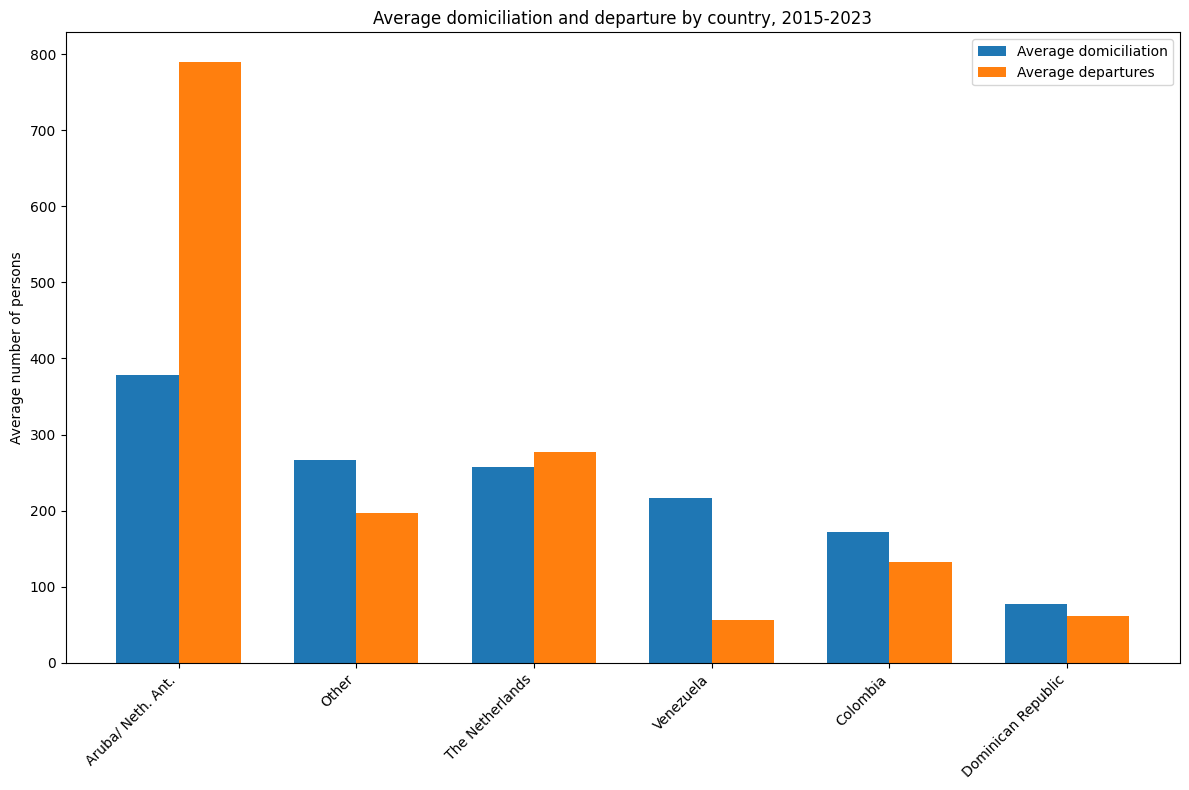

In [13]:
summary.index = summary.index.str.strip()
plot_df = summary[~summary.index.str.startswith("Total")].copy()

plot_df = plot_df.sort_values(by="mean_domiciliation", ascending=False)

x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(12,8))

plt.bar(x - width/2, plot_df["mean_domiciliation"], width, label="Average domiciliation")
plt.bar(x + width/2, plot_df["mean_departures"], width, label="Average departures")

plt.xticks(x, plot_df.index, rotation=45, ha="right")
plt.ylabel("Average number of persons")
plt.title("Average domiciliation and departure by country, 2015-2023")
plt.legend()
plt.tight_layout()

plt.show()

The figure shows average domiciliation and departures by country category across 2015–2023, excluding total rows. Aruba/ Neth. Ant. shows a structurally higher departure level, while Venezuela shows a consistently higher domiciliation level relative to departures.

Domiciliation alone only shows one side of Aruba’s registration dynamics. By comparing formal resident registrations with recorded departures, a more nuanced picture emerges: some origin categories show a consistently positive registration balance, while others show structurally higher departures. This distinction matters because population movement is not simply about arrival, but also about exit, registration, and administrative visibility.

---

## 3. Standardize column names and create 'Total' rownames

In [15]:
# Renaming of column names for easier matching during analysis

dom_df = dom_df.rename(columns={"Country":"country",
                          "value":"domiciliation"
                         })

dep_df = dep_df.rename(columns={"Country":"country",
                         "value":"departures"
                        })

In [16]:
dom_df["country"] = dom_df["country"].replace({
    "Total Domiciliation:":"Total"
})

dep_df["country"] = dep_df["country"].replace({
        "Total Departures:":"Total"
    })

### 3-1. Extra cleaning step to make sure all possible extra spaces get removed

In [17]:
dom_df["country"] = dom_df["country"].str.strip()
dep_df["country"] = dep_df["country"].str.strip()

dom_df["sex"] = dom_df["sex"].str.strip()
dep_df["sex"] = dep_df["sex"].str.strip()

In [18]:
# Sanity check in case of duplicates

key_cols = ["country", "year", "sex"]

print(dom_df[key_cols].duplicated().sum())
print(dep_df[key_cols].duplicated().sum())

0
0
